In [16]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import os
import pickle

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from adaptive_smc.save_and_read_and_postprocess import acf2, correct_acf, acf


# if there are too many dimension, we can restrict the samples to the marginal of the component of interest,
# and compute the acf for the marginal sampler
LOAD_MARGINAL = False
LOAD_COMPONENT_IDX = 1

PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR + file, "rb"))
        if LOAD_MARGINAL:
            loaded =  {'res': (loaded['res'][0][:,:,0,jnp.newaxis,..., LOAD_COMPONENT_IDX, jnp.newaxis], None, None, None, None, None, loaded['res'][6], None, None, None), 'config':loaded['config']}
        else:
            loaded = {'res': (loaded['res'][0][:,:,0,jnp.newaxis,...], None, None, None, None, None, loaded['res'][6], None, None, None), 'config':loaded['config']}
        PKLs.append(loaded)
        PKL_titles.append(str(file))
n = len(PKLs)

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [17]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])

mapping_labels = {'build_build_autoregressive_gaussian_proposal' : 'pCN',
'build_gaussian_rwmh_cov_proposal_gamma' : 'adaptive RW',
'build_build_uncoupled_autoregressive_gaussian_proposal' : r"ARW"}

idx_proposal = {mapping_labels[proposal]: idx_proposal[proposal] for proposal in idx_proposal}
print(idx_proposal)

{'pCN': [0]}


In [ ]:
"""
Only if ~MARGINAL.
"""
max_lag = 10

colors = ["blue", "orange", "green"]
ls = ["--", "-.", ":"]
alphas = [1., 0.5]
component_idx = 2

plt.figure(figsize=(12, 7))

for p_idx, proposal in enumerate(idx_proposal):
    max_temp_idx = min(12, max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in idx_proposal[proposal]]))
    samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0)
    acfs = correct_acf(samples, max_lag)[..., 0, 0]
    for idx_it, it in enumerate([1, 5]):
        marker = ['o', 's', '^'][idx_it % 3]  # Use different markers for clarity
        plt.plot(np.arange(1, max_lag+1), acfs[:, it], 
                 marker=marker, 
                 label=f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it==0 else None,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linestyle=ls[idx_it],
                 linewidth=1.5)

# Beautify plot
plt.xlabel("Lag", fontsize=12)
plt.ylabel("Estimated Autocorrelation", fontsize=12)
#plt.title("Autocorrelation Function by Proposal and Iteration", fontsize=13)
plt.xticks(ticks=np.arange(1, max_lag+1, 1))  # Only integer x-ticks
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()


In [7]:
for proposal in idx_proposal:
    for idx in idx_proposal[proposal]:
        if PKLs[idx]['res'][0] is None:
            print(idx)
            print(PKL_titles[idx])

In [19]:
PKLs[0]['res'][0].shape

(1, 4, 1, 8, 1001, 100)

/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float32 to dtype=float16 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


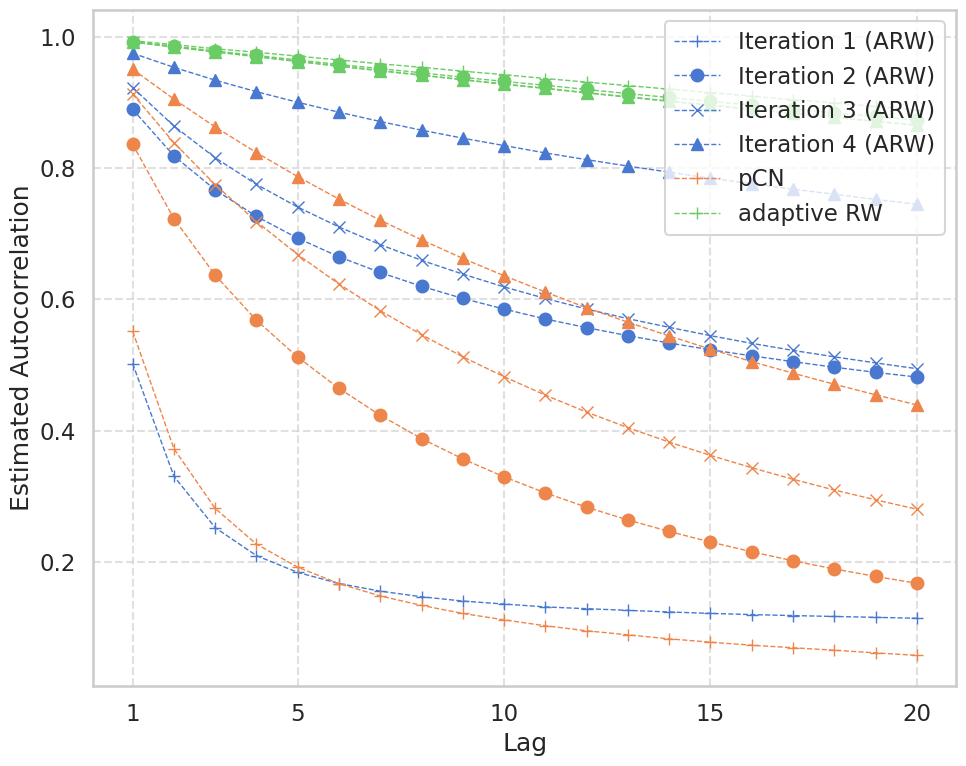

In [108]:
LAG = 20 # from 1 to 20 
xticks = np.arange(1, LAG+1)
display_x_ticks = np.concatenate([[1], np.arange(5, LAG+1, 5)])

# if there are too many dimension, we can restrict the samples 
# to the marginal of the component of interest,
# and compute the acf for the marginal samplers

MARGINAL_ACF = True 
MARGINAL_ACF += LOAD_MARGINAL
ACF_COMPONENT_IDX = 1

if ACF_COMPONENT_IDX != LOAD_COMPONENT_IDX and LOAD_MARGINAL:
    raise Exception("You cannot compute the ACF on a discarded component")



# Match Seaborn style
sns.set(style='whitegrid', context='talk', palette='muted')

colors = sns.color_palette('muted')[:3]
alphas = [1.0, 1.0, 1.0, 1.0]

plt.figure(figsize=(10, 8))

for p_idx, proposal in enumerate(idx_proposal):
    if MARGINAL_ACF and not LOAD_MARGINAL:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0) # tricks to avoid computing full acf since we are interested only in diagonal terms
        acfs = correct_acf(samples, max_order=LAG)[..., 0, 0]
    elif LOAD_MARGINAL:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ...] for idx in idx_proposal[proposal]], axis=0) # tricks to avoid computing full acf since we are interested only in diagonal terms
        acfs = correct_acf(samples, max_order=LAG)[..., 0, 0]
    else:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0] for idx in idx_proposal[proposal]], axis=0)
        acfs = correct_acf(samples, max_order=LAG)[..., component_idx, component_idx]
    for idx_it, it in enumerate([1, 2, 3, 4]):
        marker = ['+', 'o', 'x', '^'][idx_it % 4]
        label = f"Iteration {it} ({proposal})" if p_idx == 0 else f"{proposal}" if idx_it == 0 else None
        plt.plot(xticks, acfs[:, it], 
                 marker=marker, 
                 label=label,
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1,
                 linestyle="--")

# Beautify to match boxplot
plt.xlabel("Lag")
plt.ylabel("Estimated Autocorrelation")
plt.xticks(ticks=display_x_ticks)
plt.legend(loc='upper right')

plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.savefig(DIR + "ACF.pdf", dpi=300)
plt.show()


/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float32 to dtype=float16 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


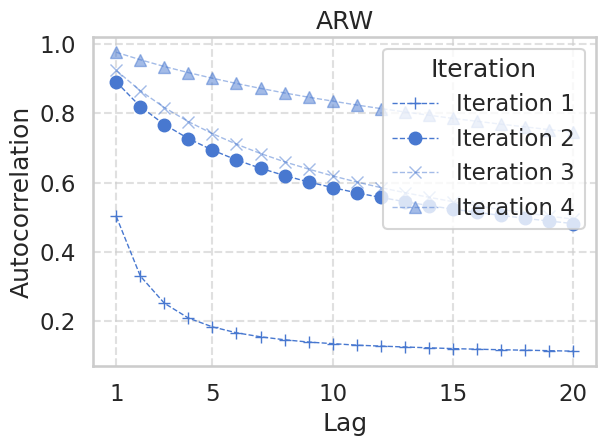

/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float32 to dtype=float16 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


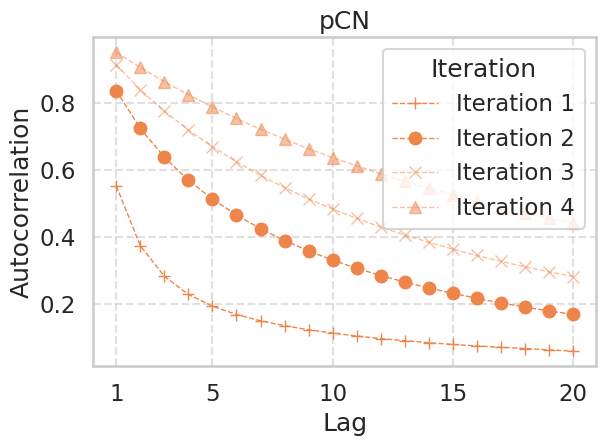

/home/onyxia/miniconda3/envs/smc/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float32 to dtype=float16 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


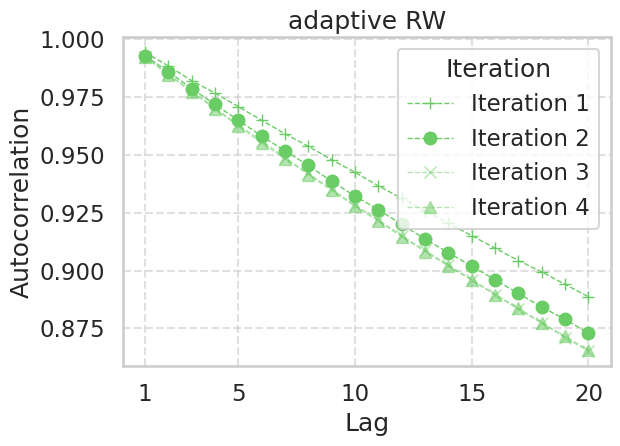

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

LAG = 20  # from 1 to 20 
xticks = np.arange(1, LAG+1)
display_x_ticks = np.concatenate([[1], np.arange(5, LAG+1, 5)])

MARGINAL = True  # Use marginal samples if True

# Match Seaborn style
sns.set(style='whitegrid', context='talk', palette='muted')

colors = sns.color_palette('muted')[:3]
alphas = [1., 1., 0.5, 0.5]
component_idx = 1

# Create a figure for each proposal
for p_idx, proposal in enumerate(idx_proposal):
    if MARGINAL_ACF and not LOAD_MARGINAL:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., component_idx, jnp.newaxis] for idx in idx_proposal[proposal]], axis=0) # tricks to avoid computing full acf since we are interested only in diagonal terms
        acfs = correct_acf(samples, max_order=LAG)[..., 0, 0]
    elif LOAD_MARGINAL:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ...] for idx in idx_proposal[proposal]], axis=0) # tricks to avoid computing full acf since we are interested only in diagonal terms
        acfs = correct_acf(samples, max_order=LAG)[..., 0, 0]
    else:
        samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0] for idx in idx_proposal[proposal]], axis=0)
        acfs = correct_acf(samples, max_order=LAG)[..., component_idx, component_idx]
    
    # Plot lines for each iteration
    for idx_it, it in enumerate([1, 2, 3, 4]):
        marker = ['+', 'o', 'x', '^'][idx_it % 4]
        plt.plot(xticks, acfs[:, it], 
                 marker=marker, 
                 label=f"Iteration {it}",
                 color=colors[p_idx], 
                 alpha=alphas[idx_it],
                 linewidth=1,
                 linestyle="--")
    
    # Customize each plot
    plt.title(f"{proposal}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.xticks(ticks=display_x_ticks)
    plt.legend(title='Iteration', loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(DIR + f"ACF_{proposal}.pdf", dpi=300)
    plt.show()

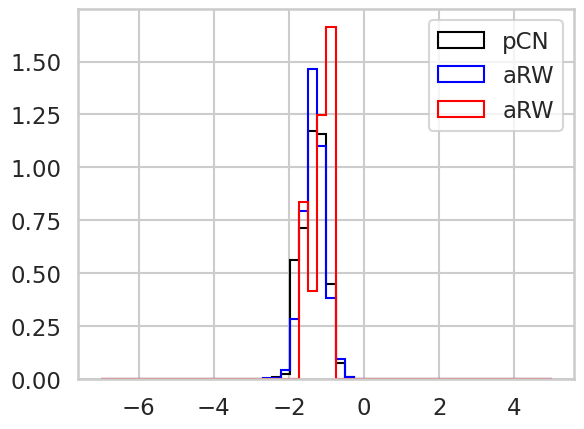

In [24]:
t=6
plt.hist(PKLs[0]['res'][0][0][t, 0, ..., 0].reshape(-1),bins=50,density=True,histtype='step',color='black', range=[-7, 5], label="pCN")
plt.hist(PKLs[1]['res'][0][0][t, 0, ..., 0].reshape(-1),bins=50,density=True,histtype='step',color='blue', range=[-7, 5], label="aRW")
plt.hist(PKLs[2]['res'][0][0][t, 0, ..., 0].reshape(-1),bins=50,density=True,histtype='step',color='red', range=[-7, 5], label="aRW")
plt.legend()